# US Equities Panel: Model-Based Features

Every feature in [`03_financial_features`](03_financial_features.ipynb) is a function of
past bars: hand it a row's history and it returns the same value whatever else the panel
contains. A feature on this page is a function of *parameters estimated from* bars, so the
estimation window is part of what the feature knows, and a parameter fitted once on the
whole sample carries the whole sample into every row it touches - including the rows a
model will later be scored on.

The discipline that removes it is an **estimation schedule**. Each model spends a burn-in
of history, is fitted on everything before the block it is about to speak for, emits values
over that block, and is then re-estimated on everything up to the start of the next one.
A value at a date is therefore a function of that date's own past and of parameters
estimated strictly earlier, at every date rather than only after some window closed. The
schedule is what bounds an estimate here; a cross-validation fold selects rows and bounds
nothing, so this artifact carries one value per stock-date whichever fold later reads it.

Three transforms are built that way, each explained where it is used:

1. **A regime distance.** Recent months of market-wide return are compared against two
   reference months learned from the history before them, and each date is given how far it
   sits from the nearer of them. Section 2.
2. **A fractionally differenced price.** A price level is differenced to a fractional order,
   which keeps part of what the level knows where a return keeps none of it. The weights
   follow from the order alone, so nothing here is estimated and there is no schedule to
   put it on. Section 3.
3. **A conditional volatility.** Every stock with enough history gets its own volatility
   model, re-estimated on the schedule and run forward between estimates; a stock too short
   to pay the burn-in takes a market-level fit. Section 4.

## Learning objectives

By the end of this notebook you will be able to:

- Tell apart the two date ranges any fitted feature has - the range its parameters were
  estimated from, and the range it produces values over - and keep the first one entirely
  before the second
- Read an estimation schedule off a calendar: what the burn-in costs, how often the
  parameters are refreshed, and where re-estimation stops so the holdout is never fitted on
- Chart how a model's fitted parameters move as the schedule advances, and use that to
  decide how often the model is worth re-estimating
- Measure what a differencing order costs in the memory it discards and buys in the
  stationarity it gains, rather than adopting the number a library defaults to
- Score how well a single column ranks stocks against their later returns, using only test
  rows, correcting the standard error for the persistence of the series and the test's
  threshold for the number of columns tried

## Book reference, prerequisites and artifacts

Chapter 9, Sections 9.1 (Stationarity), 9.3 (Volatility), 9.5 (Regimes). Assumes
[`02_labels`](02_labels.ipynb) and [`03_financial_features`](03_financial_features.ipynb)
have been run.

Reads the adjusted daily panel through `load_us_equities()`, `config/setup.yaml` for the
estimation schedule, the fold design and the holdout boundary, and the primary label file
written by [`02_labels`](02_labels.ipynb) for the ranking check in Section 7. Writes
`features/model_based.parquet`, which the model stages join to the stage-03 matrix on
`(symbol, timestamp)`, alongside a small companion file recording what was written - the
digest sidecar Section 6 describes.

In [1]:
"""US Equities Panel: Model-Based Features."""

import gc
import multiprocessing
import os
from concurrent.futures import ProcessPoolExecutor
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from arch import arch_model
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from ml4t.engineer.features.fdiff import ffdiff, get_ffd_weights
from numpy.typing import NDArray
from statsmodels.tsa.stattools import adfuller

from case_studies.utils.artifact_digest import read_digest, value_digest
from case_studies.utils.coverage import assert_sessions_complete
from case_studies.utils.cv_window import modeling_fold_boundaries
from case_studies.utils.temporal import (
    fit_wasserstein_kmeans,
    garch11_conditional_volatility,
    lift_stream,
    refit_boundaries,
    walk_forward_feature,
    wasserstein_distance_1d,
    write_model_based,
)
from data import load_us_equities
from utils.artifact_specs import resolve_label_horizon
from utils.cv_splits import select_folds
from utils.data_quality import top_entities
from utils.paths import display_path, get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

CASE_DIR = get_case_study_dir("us_equities_panel")
FEATURES_DIR = CASE_DIR / "features"

# The eligibility screen, carried by 02_labels and 03_financial_features from the same three
# constants on the same columns, so all three stages screen one universe.
MIN_ADV_USD = 1_000_000
MIN_PRICE = 5.0
ADV_WINDOW = 21

# Transform parameters. These define the transforms rather than the strategy, so they are
# declared here; everything that defines the strategy is bound from setup.yaml below.
FFD_D = 0.4  # equity-class default; Section 3 measures what it costs and buys
FFD_D_GRID = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
FFD_THRESHOLD = 1e-5

FDR_ALPHA = 0.05

FloatArray = NDArray[np.float64]

### The values a run can be given

These are the only ones a caller overrides, so they sit in their own cell where Papermill
can reach them, and nothing below re-assigns them. What each decides:

- **`START_DATE`** is the first session the price panel is read from. It has to match the
  date `02_labels` ran from, because Section 1 asserts that the panel this notebook reads
  digests to the value recorded against the label file Section 7 scores against.
- **`MAX_FOLDS`** keeps only the *n* earliest cross-validation folds. Zero, the default,
  keeps all of them. The folds select the rows Section 7 scores and bound no estimate, so a
  shortened run measures the same features over a shorter span.
- **`MAX_SYMBOLS`** caps how many stocks are given their own volatility model, taking the
  ones with the most return history through `top_entities`. Zero, the default, fits every
  stock that clears the burn-in. It does **not** reduce the panel, and that is deliberate:
  the regime and market volatility features are computed from the cross-sectional median,
  and a median over five stocks is not a market. The cost is that a capped run here and a
  capped `05_evaluation` rank over different frames - complete return histories against the
  rows that survive eligibility, the fold windows and the label join - so the two sets can
  differ, and a stock 05 scores but 04 did not fit carries the market-level volatility
  through the coalesce in Section 5. Nothing here detects that: Section 7's variation table
  only reports `garch_cond_vol` as market-level when *every* stock left on the date carries
  the broadcast, and a partial overlap puts fitted and substituted values in one column that
  still varies across the cross-section. Set the two caps to the same value only after
  checking that they select the same names, or leave this one at zero.
- **`XS_MIN_STOCKS`** is the narrowest cross-section a daily return distribution is
  summarized from. The clustering in Section 2 reads the median of that distribution, and a
  median over a handful of names is not a market. It belongs here rather than with the
  transform constants above because it is a property of the panel rather than of the
  transform: a run over fewer stocks has to lower it or every date is dropped and the
  clustering has nothing to fit on.
- **`GARCH_MIN_OBS`** and **`REGIME_MIN_OBS`** override the two burn-ins `setup.yaml`
  declares - 504 sessions of a stock's own returns before its variance model is fitted, and
  756 sessions of market history before the first clustering is. Zero, the default, takes
  the declared value. A run over a shorter history has to lower them or no series clears the
  burn-in and every block is left empty.

`SEED` fixes the one random step in the notebook, the initialization of the Wasserstein
clustering in Section 2.

In [2]:
CASE_STUDY_ID = "us_equities_panel"
START_DATE = "1990-01-01"
MAX_FOLDS = 0
MAX_SYMBOLS = 0
XS_MIN_STOCKS = 50
GARCH_MIN_OBS = 0
REGIME_MIN_OBS = 0
SEED = 42

In [3]:
set_global_seeds(SEED)

## Configuration

The estimation schedule, the fold design, the holdout boundary and the primary label come
from `config/setup.yaml`. The label's horizon is what binds Section 7: an IC series scored
on a one-session forward return needs its Newey-West lag set from that horizon, and the
validation window it may be scored over ends one session before the holdout opens rather
than on the holdout date.

The horizon is stated in sessions and the buffer in calendar days because that is how the
splitter takes them. A buffer of one day is the gap the walk-forward design leaves between
the last training session of a fold and the first session it is scored on, so that the
outcome of the last training decision is already known when the validation window opens.

The schedule is two numbers per model: how much history it spends before its first estimate,
and how many sessions an estimate speaks for before the next one replaces it. Both are
declared rather than searched, and Section 4b measures what the cadence buys.

In [4]:
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_HORIZON = int(resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP).rstrip("Dd"))
LABEL_BUFFER = SETUP["labels"]["buffer"]
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
END_DATE = str(SETUP["evaluation"]["holdout_end"])
CALENDAR = SETUP["evaluation"]["calendar"]

_REGIME = SETUP["model_based"]["regime"]
_GARCH = SETUP["model_based"]["garch"]
N_CLUSTERS = int(_REGIME["n_clusters"])
WASSERSTEIN_WINDOW = int(_REGIME["window"])
WASSERSTEIN_OVERLAP = int(_REGIME["overlap"])
REGIME_BURNIN = REGIME_MIN_OBS or int(_REGIME["burnin"])
REGIME_REFIT_EVERY = int(_REGIME["refit_every"])
GARCH_BURNIN = GARCH_MIN_OBS or int(_GARCH["burnin"])
GARCH_REFIT_EVERY = int(_GARCH["refit_every"])

print(
    f"Regime model: {N_CLUSTERS} states clustered from {WASSERSTEIN_WINDOW}-session windows "
    f"overlapping by {WASSERSTEIN_OVERLAP}, after a {REGIME_BURNIN}-session burn-in and "
    f"re-estimated every {REGIME_REFIT_EVERY} sessions."
)
print(
    f"Volatility model: one GARCH(1,1) per stock after a {GARCH_BURNIN}-session burn-in, "
    f"re-estimated every {GARCH_REFIT_EVERY} sessions."
)
print(
    f"Section 7 scores against {PRIMARY_LABEL}, the return over the next {LABEL_HORIZON} "
    f"session(s), so its Newey-West lag is set from {LABEL_HORIZON}."
)
print(
    f"The walk-forward design leaves {LABEL_BUFFER} between a fold's last training session "
    "and the first session it is scored on."
)
print(
    f"Everything from {HOLDOUT_START} to {END_DATE} is held out: no parameter here is "
    "estimated from it, and no number here is measured on it."
)
print(
    f"A stock is eligible on a date when its printed close is above ${MIN_PRICE:.0f} and its "
    f"dollar volume has averaged above ${MIN_ADV_USD:,} over the previous {ADV_WINDOW} "
    "sessions - the screen 02_labels and 03_financial_features apply."
)

Regime model: 2 states clustered from 21-session windows overlapping by 5, after a 756-session burn-in and re-estimated every 63 sessions.
Volatility model: one GARCH(1,1) per stock after a 504-session burn-in, re-estimated every 63 sessions.
Section 7 scores against fwd_ret_1d, the return over the next 1 session(s), so its Newey-West lag is set from 1.
The walk-forward design leaves 1D between a fold's last training session and the first session it is scored on.
Everything from 2016-01-01 to 2018-03-31 is held out: no parameter here is estimated from it, and no number here is measured on it.
A stock is eligible on a date when its printed close is above $5 and its dollar volume has averaged above $1,000,000 over the previous 21 sessions - the screen 02_labels and 03_financial_features apply.


## Why this panel is given regime and volatility features

The strategy this case study builds ranks stocks cross-sectionally and holds the top names
against the bottom ones. A ranking like that earns steadily for long stretches and then
gives several years back in a few weeks, and the weeks it gives them back in are the ones
where the market turns sharply after a decline - Daniel and Moskowitz (2016) call these
momentum crashes and show they cluster where volatility is high and the market is
rebounding. A model that only sees each stock's own price history has no way to tell those
weeks apart from any other.

So the three transforms fitted below each supply something a per-stock price feature cannot:

- **Where the whole cross-section currently sits.** The Wasserstein clustering in Section 2
  compares the recent month of market-wide returns against two reference months learned from
  the training window, and reports how close the match is. Its useful output is the *distance*
  rather than the state, because a crash happens while the market is between states.
- **How turbulent each stock is right now.** The GARCH fit in Section 4 gives each stock a
  conditional volatility that responds to its own recent moves, which is the quantity the
  crash literature conditions on.
- **A price level that is still usable as a regressor.** Fractional differencing in Section 3
  keeps part of what the level of a price knows, which a return has thrown away entirely.

None of the three is a trading rule. They are inputs a model in the later stages can
condition on, and whether conditioning on them helps is a question for `05_evaluation` and
the model notebooks, not for this page.

## 1. Load the panel and screen it

Two screens run here, and they are the ones
[`02_labels`](02_labels.ipynb) and [`03_financial_features`](03_financial_features.ipynb)
already run, rebuilt from the same constants on the same columns so that all three stages
describe one universe.

**Sessions are numbered first.** The archive carries a small number of stray prints on dates
the exchange held no market. A date that was never open is not a date a position can be taken
on, and `get_sessions` identifies them: a date that maps to itself is a session, and a stray
print maps to a neighbouring one. Dropping them and numbering what is left gives a counter
whose difference between two rows is a count of sessions rather than a count of rows. Every
window on this page needs it - a variance recursion, a fractional-difference convolution and
a rolling turnover average all read their input in order and treat consecutive elements as
consecutive sessions.

**Then eligibility**, on three conditions: a printed close above \$5, dollar volume
`close * volume` averaging above \$1M over the previous month, and that month being an
unbroken run of sessions rather than whatever twenty-one rows the stock happens to have. The
first two legs read figures the tape carried on the day, so neither depends on a corporate
action that had not happened yet, and Section B of [`02_labels`](02_labels.ipynb) derives why
the adjusted close cannot serve for either. The third is what stops a stock returning from a
halt qualifying on volume it traded before the halt.

**Eligibility is applied only to what is emitted, never to what the transforms read.** On the
eligible frame a per-stock window would count *eligible* rows, so a stock that falls below a
threshold for two years and recovers would have its convolution and its variance recursion
reach straight across the excursion as though those were consecutive sessions. Both run on
the full session panel; the eligible frame decides only which rows leave this notebook.

The digest of the panel read here has to equal the one [`02_labels`](02_labels.ipynb)
recorded against the label file this notebook scores against in Section 7; the assertion
below is what makes the two files comparable rather than merely both present.

In [5]:
# The six columns this notebook reads, and `lazy=True` so the projection reaches the parquet
# scan rather than a frame that has already been read. The archive carries fourteen columns
# over 14.5M rows, and the eight not named here - the unadjusted open, high and low, their
# adjusted counterparts, the dividend and the split ratio - are read nowhere on this page.
# Selecting after an eager load still materializes all eight: 1.40 GB against 0.53 GB, at a
# peak of 2.88 GB against 1.66 GB, measured on 2026-09-10.
#
# The digest below is the reason this is safe to assert rather than merely likely.
# `value_digest` hashes the columns it is given and nothing else, and all five it is given
# are among the six: loading both ways on 2026-09-10 returned 81db7d7920165013 either way,
# which is the value `02_labels` recorded against the label file.
READ_COLS = ["symbol", "timestamp", "close", "volume", "adj_close", "adj_volume"]

raw_df = (
    load_us_equities(start_date=START_DATE, end_date=END_DATE, lazy=True)
    .select(READ_COLS)
    .collect()
)

if raw_df.schema["timestamp"] == pl.Datetime:
    raw_df = raw_df.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))

raw_df = raw_df.sort(["symbol", "timestamp"])

MARKET_DATA_DIGEST = value_digest(raw_df, ["symbol", "timestamp", "close", "volume", "adj_close"])
LABEL_INPUT_DIGEST = read_digest(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")["inputs"][
    "market_data"
]
print(f"market_data digest: {MARKET_DATA_DIGEST}")
assert MARKET_DATA_DIGEST == LABEL_INPUT_DIGEST, (
    f"the labels were written against market_data {LABEL_INPUT_DIGEST} and this stage read "
    f"{MARKET_DATA_DIGEST}. Re-run 02_labels before scoring features against its output."
)

market_data digest: 81db7d7920165013


In [6]:
# The session counter, built exactly as 02_labels and 03_financial_features build it.
_dates = raw_df.select("timestamp").unique().sort("timestamp")
_settling_session = pl.Series(
    TradingCalendar(CALENDAR)
    .get_sessions(pd.DatetimeIndex(_dates["timestamp"].to_list(), tz="UTC"))
    .to_numpy()
).cast(pl.Date)
_sessions = (
    _dates.filter(_settling_session == pl.col("timestamp"))
    .with_row_index("session")
    .with_columns(pl.col("session").cast(pl.Int64))
)
_archive_rows = raw_df.height
raw_df = raw_df.join(_sessions, on="timestamp", how="inner").sort(["symbol", "timestamp"])
print(
    f"{_sessions.height:,} of {_dates.height:,} dates in the archive are {CALENDAR} sessions; "
    f"the other {_dates.height - _sessions.height} carry stray prints and take "
    f"{_archive_rows - raw_df.height:,} rows with them"
)

# The archive is missing one session the exchange held, `2017-11-08`, a Wednesday. It is absent
# UPSTREAM - the raw archive carries no row on it - so no stage of this case study drops it, and
# over the whole archive, 1962-01-02 to 2018-03-27, it is the only NYSE session of 14,156 that is
# absent. It is declared here so it passes deliberately, and so a second one refuses instead.
#
# The filter above answers one direction only: which archive dates the exchange never held. The
# other direction, a session the exchange DID hold that the archive never printed, leaves no row
# to test - nothing raises, every query succeeds, and one day's rows are simply gone. That is how
# this one survived until two counts of an unrelated quantity came out one apart.
KNOWN_ABSENT_SESSIONS = [date(2017, 11, 8)]

_declared = assert_sessions_complete(
    _sessions["timestamp"].to_list(),
    calendar=CALENDAR,
    known_absent=KNOWN_ABSENT_SESSIONS,
    source="04_model_based_features session index",
)
print(
    f"Every {CALENDAR} session between {_sessions['timestamp'].min()} and "
    f"{_sessions['timestamp'].max()} is in the archive except {_declared}, which is declared "
    "above"
)

7,114 of 7,234 dates in the archive are NYSE sessions; the other 120 carry stray prints and take 165 rows with them


Every NYSE session between 1990-01-02 and 2018-03-27 is in the archive except [datetime.date(2017, 11, 8)], which is declared above


In [7]:
raw_df = raw_df.with_columns(
    (pl.col("adj_close") / pl.col("adj_close").shift(1).over("symbol") - 1).alias("returns"),
    (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
)
raw_df = raw_df.with_columns(
    pl.col("dollar_volume").rolling_mean(ADV_WINDOW).over("symbol").alias("adv_21d"),
    (pl.col("session") - pl.col("session").shift(ADV_WINDOW - 1) == ADV_WINDOW - 1)
    .over("symbol")
    .alias("adv_covered"),
)

ELIGIBLE = pl.col("adv_covered") & (pl.col("close") > MIN_PRICE) & (pl.col("adv_21d") > MIN_ADV_USD)
df = raw_df.filter(ELIGIBLE)

print(
    f"{len(raw_df):,} session rows on {raw_df['symbol'].n_unique():,} symbols, "
    f"{raw_df['timestamp'].min()} to {raw_df['timestamp'].max()}"
)
print(
    f"{len(df):,} of them on {df['symbol'].n_unique():,} symbols pass all three conditions and "
    "are eligible to be emitted"
)

14,498,765 session rows on 3,199 symbols, 1990-01-02 to 2018-03-27
9,978,112 of them on 3,178 symbols pass all three conditions and are eligible to be emitted


Those two totals are sums over twenty-eight years, and what every transform below actually
works with is one day's slice of the panel. The figure is that slice through time: how many
stocks are eligible on each session, with the two thresholds that read the count drawn across
it.

It is worth looking at before anything is fitted, because two of the decisions on this page
are decisions about that count. The clustering in Section 2 takes a median across the slice
and skips any date holding fewer than `XS_MIN_STOCKS` names, so where that line sits relative
to the curve says whether the threshold ever binds. And the count rises for most of the
sample before turning down, which is why two windows of the same length in sessions are not
comparable in how many stocks they saw.

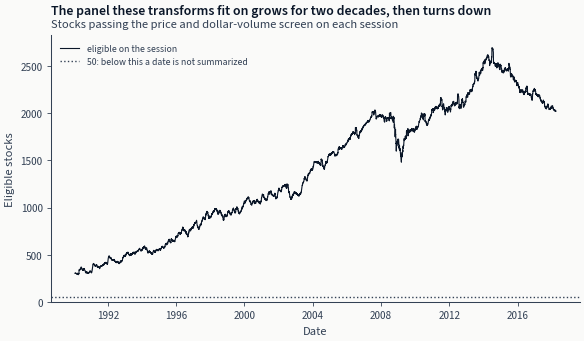

In [8]:
_coverage = df.group_by("timestamp").len().sort("timestamp")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(
    _coverage["timestamp"],
    _coverage["len"],
    color=COLORS["blue"],
    lw=0.8,
    label="eligible on the session",
)
ax.axhline(
    XS_MIN_STOCKS,
    color=COLORS["neutral"],
    ls=":",
    lw=1.0,
    label=f"{XS_MIN_STOCKS}: below this a date is not summarized",
)
ax.set_ylim(0, None)
ax.set_xlabel("Date")
ax.set_ylabel("Eligible stocks")
ax.legend(frameon=False, fontsize=7, loc="upper left")
add_message_title(
    ax,
    "The panel these transforms fit on grows for two decades, then turns down",
    subtitle="Stocks passing the price and dollar-volume screen on each session",
)
show_with_alt(
    fig,
    "A single line counts the stocks eligible on each session across the sample. It climbs "
    "for about two decades, drops sharply in the 2008 crisis, recovers to its highest point "
    "and then declines over the final years. One flat reference line sits far below it, "
    "marking the count below which a date is not summarized; the eligible-stock line stays "
    "above it throughout.",
)

## 1b. What bounds an estimate, and what selects a row

**A schedule bounds an estimate.** Each model below spends a burn-in, is fitted on the
sessions before the block it is about to speak for, emits values over that block, and is
re-estimated on everything up to the start of the next one. No session is ever used to fit
the model that describes it, at any position in the series rather than only after some
window closed. Past `holdout_start` nothing is re-estimated: the last estimate made on
development sessions carries the rest, because a coefficient refitted on a held-out session
is a parameter estimated from the holdout however causal the recursion around it looks.

**A fold selects rows.** The walk-forward folds are resolved here because Section 7 scores
each column over the sessions the folds validate on, and because the figure below is worth
looking at before anything is fitted. They enter no fit and they are not a key of the
artifact: a stock-date carries one value whichever fold later reads it.

**They are resolved from the label file, through the same call the model stages use.** A
walk-forward splitter counts backward from the holdout boundary in rows of whatever frame it
is handed, and it seals the end of each validation window by the horizon of the label being
predicted. Both of those are properties of the label file, not of the price panel, and
`modeling_fold_boundaries` reads the label file's own date index and its own configured
buffer and horizon. It is what `load_modeling_dataset` calls on the other side of the join,
so the sessions this notebook scores on are the sessions a model is validated on rather
than a second set that happens to carry the same numbers.

**Both ends of a window are inclusive**: `train_end` is the last session a fold trains on
and `val_end` the last session it is scored on.

In [9]:
holdout_start = date.fromisoformat(HOLDOUT_START)
holdout_end = date.fromisoformat(END_DATE)

# The trading calendar the folds are counted on, taken from the label file itself.
SESSIONS = sorted(
    pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")["timestamp"]
    .unique()
    .to_list()
)

# Ordered by the sessions they score, so the printout below reads chronologically. The
# `MAX_FOLDS` reduction underneath names the fold ids it keeps rather than taking a head
# slice of that order, which is a count that says nothing about which windows it kept.
folds = sorted(
    (
        {
            "fold": split["fold"],
            "train_start": split["train_start"],
            "train_end": split["train_end"],
            "test_start": split["val_start"],
            "test_end": split["val_end"],
        }
        for split in modeling_fold_boundaries(CASE_STUDY_ID, PRIMARY_LABEL)
    ),
    key=lambda f: f["test_start"],
)
if MAX_FOLDS > 0:
    folds = select_folds(folds, range(MAX_FOLDS))

print(f"{len(folds)} cross-validation folds, which select rows and bound no estimate:")
for f in folds:
    print(
        f"  Fold {f['fold']}: trained on {f['train_start']} to {f['train_end']}, "
        f"scored on {f['test_start']} to {f['test_end']}"
    )

# The one condition Section 7 rests on, asserted rather than described: a validation window
# that crept past the boundary would still be scored and still print a table.
for f in folds:
    assert f["train_end"] < f["test_start"], f"fold {f['fold']} trains into its own validation"
    assert f["test_end"] < holdout_start, (
        f"fold {f['fold']} is scored through {f['test_end']}, past the holdout opening "
        f"{holdout_start}"
    )
print(f"  every validation window closes before {holdout_start}")

16 cross-validation folds, which select rows and bound no estimate:
  Fold 0: trained on 1990-01-30 to 1999-12-20, scored on 1999-12-22 to 2000-12-19
  Fold 1: trained on 1991-01-15 to 2000-12-18, scored on 2000-12-20 to 2001-12-26
  Fold 2: trained on 1992-01-14 to 2001-12-24, scored on 2001-12-27 to 2002-12-26
  Fold 3: trained on 1993-01-12 to 2002-12-24, scored on 2002-12-27 to 2003-12-26
  Fold 4: trained on 1994-01-10 to 2003-12-24, scored on 2003-12-29 to 2004-12-28
  Fold 5: trained on 1995-01-10 to 2004-12-27, scored on 2004-12-29 to 2005-12-27
  Fold 6: trained on 1996-01-09 to 2005-12-23, scored on 2005-12-28 to 2006-12-27
  Fold 7: trained on 1997-01-07 to 2006-12-26, scored on 2006-12-28 to 2007-12-28
  Fold 8: trained on 1998-01-06 to 2007-12-27, scored on 2007-12-31 to 2008-12-29
  Fold 9: trained on 1999-01-06 to 2008-12-26, scored on 2008-12-30 to 2009-12-29
  Fold 10: trained on 2000-01-05 to 2009-12-28, scored on 2009-12-30 to 2010-12-29
  Fold 11: trained on 2001-01

In [10]:
def in_validation_windows(column: str = "timestamp") -> pl.Expr:
    """True on a session inside any cross-validation fold's validation window."""
    spans = [
        (pl.col(column) >= pl.lit(f["test_start"]).cast(pl.Date))
        & (pl.col(column) <= pl.lit(f["test_end"]).cast(pl.Date))
        for f in folds
    ]
    expr = spans[0]
    for span in spans[1:]:
        expr = expr | span
    return expr

Each row of the figure is one fold: the filled bar is the span it trains on, the open bar
the span it is scored on, and the dashed rule is the date the holdout opens. The windows
roll back one year at a time and no open bar crosses the rule, so every column Section 7
scores is scored on development sessions.

There is no estimation window on this figure, because a fold does not carry one. Section
4b draws the schedule that bounds the estimates.

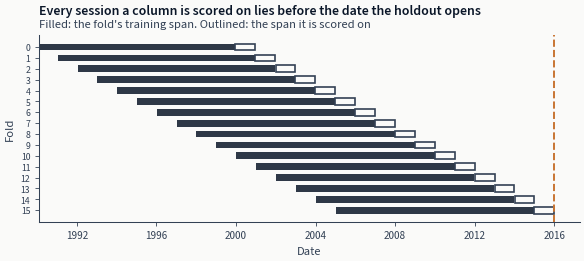

In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
for row, f in enumerate(folds):
    tr0, tr1 = f["train_start"], f["train_end"]
    te0, te1 = f["test_start"], f["test_end"]
    ax.barh(row, (tr1 - tr0).days, left=tr0, height=0.62, color=COLORS["blue"], alpha=0.85)
    ax.barh(
        row,
        (te1 - te0).days,
        left=te0,
        height=0.62,
        facecolor="none",
        edgecolor=COLORS["neutral"],
        linewidth=1.2,
    )
ax.axvline(holdout_start, color=COLORS["copper"], ls="--", lw=1.4)
ax.set_yticks(range(len(folds)))
ax.set_yticklabels([str(f["fold"]) for f in folds], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Date")
ax.set_ylabel("Fold")
add_message_title(
    ax,
    "Every session a column is scored on lies before the date the holdout opens",
    subtitle="Filled: the fold's training span. Outlined: the span it is scored on",
)
show_with_alt(
    fig,
    "One horizontal row per cross-validation fold. Each row is a long filled bar for the "
    "window the fold trains on, followed by a short outlined bar for the window it is scored "
    "on. The pairs step later in time down the rows. A dashed vertical line marks the date "
    "the holdout opens, and no bar of either kind crosses it.",
)

## 2. Wasserstein regime distance

At each date the median return is taken across every eligible stock trading that day. That
one number per date is how the centre of the whole cross-section moves, and it is the series
everything in this section reads.

The method compares one recent month of that series against reference months learned from
the training window, and it needs a way to say how far apart two months are. Two months of
returns are two collections of twenty-one numbers, and the natural comparison is not
value-by-value in date order - the same month reordered is the same market - but
distribution against distribution. The **Wasserstein distance** measures exactly that: sort
both collections, pair the smallest with the smallest and the largest with the largest, and
average how far each pair has to move. It answers "how much return would have to be shifted,
and how far, to turn one month into the other".

With a distance in hand, ordinary k-means applies. **k-means** repeatedly assigns each
window to its nearest of $k$ reference windows and then recomputes each reference as the
centre of the windows assigned to it, until the references stop moving. Those references are
called **centroids**, and with $k=2$ the two the algorithm settles on separate the calm,
mildly positive months from the falling, turbulent ones. Two states is the coarsest split
that can express that distinction, and it is the one the momentum-crash literature works in.

The centroids are re-estimated on the schedule: fitted on the market history up to a
boundary, held fixed while the next quarter of windows is scored against them, then fitted
again on everything up to the following boundary. Every stock carries the same value on a
date, because the series being clustered is market-wide.

The estimator itself - the lifting, the distance, the barycenter and the k-means around them -
is `lift_stream`, `wasserstein_distance_1d`, `wasserstein_barycenter_1d` and
`fit_wasserstein_kmeans` in `case_studies/utils/temporal.py`, beside the HMM helpers the other
case studies fit their regimes with. This notebook composes them on the schedule below.
[`09_model_based_features/12_wasserstein_regimes`](../../09_model_based_features/12_wasserstein_regimes.ipynb)
builds the same four objects from nothing, for a reader who wants to see the algorithm rather
than use it.

### The series the clustering reads

One median per date, over the eligible stocks that traded that date. Dates whose
cross-section is thinner than `XS_MIN_STOCKS` are dropped rather than summarized, because a
median over a handful of names describes those names and not the market.

In [12]:
xs_stats = (
    df.filter(pl.col("returns").is_not_null())
    .group_by("timestamp")
    .agg(
        pl.col("returns").median().alias("xs_median_ret"),
        pl.col("returns").count().alias("n_stocks"),
    )
    .sort("timestamp")
    .filter(pl.col("n_stocks") >= XS_MIN_STOCKS)
)

market_ret = xs_stats["xs_median_ret"].to_numpy()
dates = xs_stats["timestamp"].to_list()

print(
    f"{len(xs_stats):,} dates carry a cross-section of at least {XS_MIN_STOCKS} eligible "
    f"stocks and are summarized; the median date carries "
    f"{int(xs_stats['n_stocks'].median()):,}"
)

7,094 dates carry a cross-section of at least 50 eligible stocks and are summarized; the median date carries 1,439


### Fitting the centroids on the schedule

The clustering is one walk over the market series. It spends `REGIME_BURNIN` sessions
before its first fit, scores the next `REGIME_REFIT_EVERY` sessions against the centroids
that fit produced, and then re-estimates on everything up to the start of the block after
that. The reference a window is compared against was therefore learned from sessions that
close before the window opens, at every session rather than only inside a fold.

What the walk emits per date is the assigned cluster, the distance to the nearer and the
farther centroid, their ratio, and how differently the window's best and worst days sit
against the centroid it matched.

k-means labels are arbitrary - which of the two states the algorithm happens to call zero
depends on where it started - so after each fit the two are reordered by their mean, and
state zero is always the lower-return one. Without that step a downstream model would see
the same market condition under one number before a refit and the other number after it.

In [13]:
def fit_regime_centroids(train: FloatArray) -> FloatArray:
    """Cluster the training prefix into `N_CLUSTERS` reference windows, lowest mean first."""
    lifted = lift_stream(train[:, 0], WASSERSTEIN_WINDOW, WASSERSTEIN_OVERLAP)
    _, centroids = fit_wasserstein_kmeans(
        lifted.sorted_segments, n_clusters=N_CLUSTERS, random_state=SEED
    )
    return centroids[np.argsort([c.mean() for c in centroids])]


def assign_regime_features(centroids: FloatArray, prefix: FloatArray) -> FloatArray:
    """Score every session of a prefix against fitted centroids.

    One row per input row, so the walk can keep the block it asked for. A session is scored
    on the `WASSERSTEIN_WINDOW` sessions strictly before it, which is why the first
    `WASSERSTEIN_WINDOW` rows carry no value: there is no complete window behind them.
    """
    series = prefix[:, 0]
    out = np.full((len(series), 5), np.nan, dtype=float)
    if len(series) <= WASSERSTEIN_WINDOW:
        return out

    # Window ending at t-1 and starting at t-WASSERSTEIN_WINDOW, for every t from the window
    # length onwards. Sorted, because the distance below compares distributions rather than
    # dates: the same month reordered is the same market.
    windows = np.sort(
        np.lib.stride_tricks.sliding_window_view(series[:-1], WASSERSTEIN_WINDOW), axis=1
    )
    distances = np.stack(
        [wasserstein_distance_1d(windows, centroids[k][None, :]) for k in range(len(centroids))],
        axis=1,
    )
    cluster = distances.argmin(axis=1)
    nearest = centroids[cluster]
    min_dist = distances.min(axis=1)
    max_dist = distances.max(axis=1)
    tail_div = np.abs(windows[:, -5:] - nearest[:, -5:]).mean(axis=1) - np.abs(
        windows[:, :5] - nearest[:, :5]
    ).mean(axis=1)

    out[WASSERSTEIN_WINDOW:] = np.column_stack(
        [cluster, min_dist, max_dist, min_dist / (max_dist + 1e-10), tail_div]
    )
    return out

The walk is driven once over the whole market series. `freeze_after` is the count of
development sessions: past it the last pre-holdout centroids are reused rather than
re-estimated, so no clustering reads a held-out session. The burn-in has to be long enough
to lift into at least the number of windows k-means needs, which is asserted rather than
assumed - a shortened run that fell below it would return centroids fitted on two windows
and report nothing about it.

In [14]:
REGIME_COLS = [
    "wass_cluster",
    "wass_dist_min",
    "wass_dist_max",
    "wass_dist_ratio",
    "wass_tail_div",
]

_step = WASSERSTEIN_WINDOW - WASSERSTEIN_OVERLAP
_min_windows = 2 * N_CLUSTERS - 1
assert WASSERSTEIN_WINDOW + _min_windows * _step <= REGIME_BURNIN, (
    f"a {REGIME_BURNIN}-session burn-in lifts into "
    f"{max(0, (REGIME_BURNIN - WASSERSTEIN_WINDOW) // _step + 1)} windows, fewer than the "
    f"{_min_windows + 1} k-means needs to separate {N_CLUSTERS} centroids"
)

regime_fits: list[dict] = []


def _fit_and_record(train: FloatArray) -> FloatArray:
    centroids = fit_regime_centroids(train)
    regime_fits.append(
        {
            "fit_end_session": dates[len(train) - 1],
            "n_fit": len(train),
            "stress_centroid_mean": float(centroids[0].mean()),
            "normal_centroid_mean": float(centroids[-1].mean()),
            "centroid_separation": float(np.abs(centroids[-1] - centroids[0]).mean()),
        }
    )
    return centroids


regime_freeze_after = int(sum(1 for d in dates if d < holdout_start))
regime_values = walk_forward_feature(
    market_ret.reshape(-1, 1),
    timestamps=dates,
    burnin=REGIME_BURNIN,
    refit_every=REGIME_REFIT_EVERY,
    fit=_fit_and_record,
    apply=assign_regime_features,
    n_features=len(REGIME_COLS),
    freeze_after=regime_freeze_after,
)

wass_df = (
    pl.DataFrame(
        {
            "timestamp": dates,
            **{col: regime_values[:, i] for i, col in enumerate(REGIME_COLS)},
        }
    )
    # `walk_forward_feature` marks the burn-in with `np.nan`, which polars keeps as a float
    # rather than a null: without this the burn-in rows survive the drop below and the
    # artifact's null counts read as zero on a column that has no value for three years.
    .with_columns(pl.col(col).fill_nan(None) for col in REGIME_COLS)
    .drop_nulls(subset=REGIME_COLS)
    .with_columns(pl.col("wass_cluster").cast(pl.Int64))
)
regime_fit_df = pl.DataFrame(regime_fits)

print(
    f"{len(regime_fits)} clusterings over {len(dates):,} sessions, the last fitted on "
    f"sessions through {regime_fit_df['fit_end_session'].max()}; "
    f"{wass_df.height:,} sessions carry a regime value, from {wass_df['timestamp'].min()}"
)
_cluster_counts = wass_df.group_by("wass_cluster").len().sort("wass_cluster")
for row in _cluster_counts.iter_rows(named=True):
    state = "lower-return" if row["wass_cluster"] == 0 else "higher-return"
    print(f"  state {row['wass_cluster']} ({state}): {row['len']:,}")

# The schedule is the provenance, so it is checked against the schedule rather than against
# prose. Every fit consumed a prefix ending before the block it spoke for, and no fit
# consumed a held-out session.
_scheduled = refit_boundaries(len(dates), REGIME_BURNIN, REGIME_REFIT_EVERY)
_estimated = [pair for pair in _scheduled if pair[0] <= regime_freeze_after]
assert len(regime_fits) == len(_estimated), (
    f"{len(regime_fits)} clusterings against a schedule of {len(_estimated)}"
)
assert regime_fit_df["fit_end_session"].max() < holdout_start, (
    f"a clustering read sessions through {regime_fit_df['fit_end_session'].max()}, inside "
    f"the holdout opening {holdout_start}"
)
print(
    f"  every fit ended before {holdout_start}; the {len(_scheduled) - len(_estimated)} "
    "blocks past it reuse the last development estimate"
)

92 clusterings over 7,094 sessions, the last fitted on sessions through 2015-10-28; 6,338 sessions carry a regime value, from 1993-01-26
  state 0 (lower-return): 3,733
  state 1 (higher-return): 2,605
  every fit ended before 2016-01-01; the 9 blocks past it reuse the last development estimate


### What the clustering inferred, on the sessions a model is scored over

The figure draws the quantity the feature actually carries, over the sessions the folds
validate on. Every value on it was produced by centroids fitted before the window it
scores, so what is plotted is a chain of out-of-sample assignments from a hundred different
fits rather than one fit's view of the whole sample.

The line is the trailing cross-sectional median return the assignment reads; the panel
below it is the monthly share of sessions assigned to the low-return centroid. Nothing in
the fitting procedure required those sessions to be the market's stressed ones.

**The lower panel is still the weaker of the two outputs, and it is worth saying why.**
State zero is whichever centroid has the lower mean *in the history that fit read*. That
fixes the arbitrariness of k-means labelling within a fit; it does not make the number mean
the same thing from one fit to the next, because a clustering estimated through the 2008
decline and one estimated a decade later put their lower-return centroid in different
places. What the panel shows is that the assignment nonetheless lands where a reader would
expect it to: nearly every session of 2008 and 2002 is in the lower state and fewer than a
tenth of 1995's are. `wass_dist_ratio` does not have the comparability problem, because it
is a ratio of distances read against the fit that produced it. It answers a different
question, though, and the difference matters: it says how firmly the window matches
whichever centroid is nearest and discards which one that was, so a window sitting squarely
in the calm state and one sitting squarely in the stressed state both drive it toward zero.
A model that needs the direction still has to read the assignment.

The assignment is aggregated to a monthly share rather than drawn as a daily strip. Sixteen
years of daily flags give each session a fraction of a pixel, isolated days vanish, and the
reader concludes the state stopped occurring when it did not.

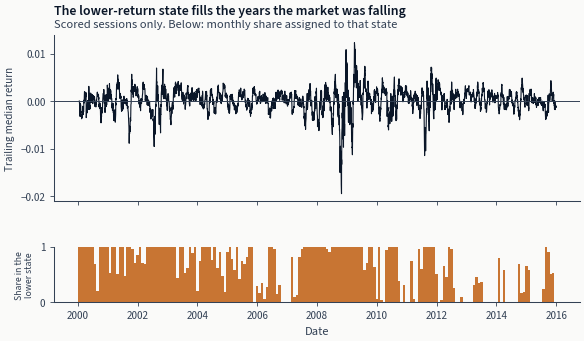

scored sessions 4,011, assigned to the lower-return state 2,552 (64%); mean trailing return -0.00021 in that state against +0.00086 in the other
  90 runs, median 5 sessions and longest 292; first assigned 2000-01-21, last 2015-12-30, and the scored span runs to 2015-12-30


In [15]:
_val_regime = wass_df.filter(in_validation_windows()).sort("timestamp")
_val_ret = xs_stats.join(_val_regime.select("timestamp", "wass_cluster"), on="timestamp").sort(
    "timestamp"
)
_smoothed = _val_ret.select(
    "timestamp",
    pl.col("xs_median_ret").rolling_mean(WASSERSTEIN_WINDOW).alias("trailing"),
    "wass_cluster",
).drop_nulls()

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=FIGSIZE["single"],
    sharex=True,
    height_ratios=[3, 1],
    gridspec_kw={"hspace": 0.22},
)
ax1.plot(_smoothed["timestamp"], _smoothed["trailing"], color=COLORS["blue"], lw=0.8)
ax1.axhline(0, color=COLORS["neutral"], lw=0.7)
ax1.set_ylabel("Trailing median return", fontsize=8)
ax1.locator_params(axis="y", nbins=4)
_monthly = (
    _smoothed.with_columns(pl.col("timestamp").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg((pl.col("wass_cluster") == 0).mean().alias("share"))
    .sort("month")
)
ax2.fill_between(_monthly["month"], 0, _monthly["share"], color=COLORS["copper"], lw=0, step="mid")
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 1])
ax2.set_ylabel("Share in the\nlower state", fontsize=7)
ax2.set_xlabel("Date")
add_message_title(
    ax1,
    "The lower-return state fills the years the market was falling",
    subtitle="Scored sessions only. Below: monthly share assigned to that state",
)
show_with_alt(
    fig,
    "Two stacked panels sharing a date axis over the scored sessions. The upper panel is a "
    "noisy trailing median return oscillating around zero, with its largest excursions in "
    "2008 and 2009. The lower panel is a filled area of the monthly share of sessions "
    "assigned to the lower-return state. It swings between the top and the bottom of the "
    "panel rather than trending: it is near the ceiling through 2000 to 2003 and again "
    "across 2008 and 2009, and close to the floor in the middle of the 1990s and again from "
    "2012 to 2014.",
)

_shaded = _smoothed.filter(pl.col("wass_cluster") == 0)
_runs = _smoothed.with_columns(
    (pl.col("wass_cluster").diff().fill_null(1) != 0).cum_sum().alias("run")
)
_run_lengths = _runs.filter(pl.col("wass_cluster") == 0).group_by("run").len()["len"]
print(
    f"scored sessions {_smoothed.height:,}, assigned to the lower-return state "
    f"{_shaded.height:,} ({_shaded.height / _smoothed.height:.0%}); mean trailing return "
    f"{_shaded['trailing'].mean():+.5f} in that state against "
    f"{_smoothed.filter(pl.col('wass_cluster') == 1)['trailing'].mean():+.5f} in the other"
)
print(
    f"  {_run_lengths.len():,} runs, median {_run_lengths.median():.0f} sessions and longest "
    f"{_run_lengths.max():,}; first assigned {_shaded['timestamp'].min()}, last "
    f"{_shaded['timestamp'].max()}, and the scored span runs to "
    f"{_smoothed['timestamp'].max()}"
)

`wass_dist_ratio` is the second thing the clustering yields: the distance to the nearer
centroid divided by the distance to the farther one. A window sitting squarely inside one
state drives it toward zero and a window equidistant from both drives it toward one, so the
feature carries how *certain* the match is rather than which state it picked. That is the
part a momentum model needs, because momentum crashes fall at the transitions rather than
inside either state.

The cost of clustering the median and nothing else is worth stating plainly: this reads a
shift in the centre of the cross-section, and a market that keeps its centre while its tails
widen looks unchanged to it. Reaching that would mean clustering quantile vectors rather than
a scalar, which is a different transform and not a tuning of this one.

## 3. Fractional differencing

A log price is not stationary and a log return has thrown away everything the level knew.
Fractional differencing (Hosking 1981; Lopez de Prado 2018) takes the difference to a
non-integer order $d$, which puts a dial between the two: at $d=0$ the series is the level
and at $d=1$ it is the first difference, and every value in between trades some memory for
some stationarity. `FFD_D` is the equity-class default this notebook uses.

**The default is measured here rather than quoted.** The cell below runs the whole grid
`FFD_D_GRID` on a sample of stocks and reports, for each order, the correlation between
the differenced series and the original log price - how much of the level's memory
is retained - against the share of sampled stocks whose augmented Dickey-Fuller test rejects
a unit root. Those are the two quantities the choice trades off, and neither is knowable
without running it.

**Nothing here is estimated, so there is no schedule to put it on.** The FFD weights are a
closed-form function of $d$ and of the truncation threshold, so the transform carries no
estimation window at all and is computed once over each stock's whole series. That makes it
the useful contrast for the sections either side of it: the hazard this stage is about is
*estimation*, not transformation, and a transform with no parameters has none of it.

In [16]:
def apply_ffd_per_symbol(
    data: pl.DataFrame, d: float = FFD_D, threshold: float = FFD_THRESHOLD
) -> pl.DataFrame:
    """Apply fractional differencing to log prices per symbol.

    Returns DataFrame with (symbol, date, ffd_log_price, ffd_log_volume).
    """
    results = []
    # Only the two columns the transform reads are partitioned. `partition_by` copies the
    # frame it is handed into one frame per symbol, so partitioning the caller's panel
    # would hold a second copy of every column on it - and this is called on the whole
    # panel, not the eligible subset.
    by_symbol = (
        data.select(["symbol", "timestamp", "adj_close", "adj_volume"])
        .sort(["symbol", "timestamp"])
        .partition_by("symbol", as_dict=True)
    )

    n_success = 0
    n_fail = 0

    for (sym,) in sorted(by_symbol):
        # Popped rather than read: the partition is dead once its result is appended, and
        # holding all of them to the end of the loop keeps a whole copy of the panel alive
        # alongside the results being built from it.
        sym_data = by_symbol.pop((sym,))

        if len(sym_data) < 100:
            n_fail += 1
            continue

        log_price = sym_data["adj_close"].log()
        # Floor volume at 1 to avoid log(0) = -inf
        log_vol = sym_data["adj_volume"].clip(lower_bound=1).log()

        try:
            ffd_price = ffdiff(log_price, d=d, threshold=threshold)
            ffd_vol = ffdiff(log_vol, d=d, threshold=threshold)

            sym_result = pl.DataFrame(
                {
                    "symbol": [sym] * len(sym_data),
                    "timestamp": sym_data["timestamp"],
                    "ffd_log_price": ffd_price,
                    "ffd_log_volume": ffd_vol,
                }
            ).drop_nulls()

            if len(sym_result) > 0:
                results.append(sym_result)
                n_success += 1
        except Exception:
            n_fail += 1

    print(f"  FFD: {n_success} symbols succeeded, {n_fail} failed/skipped")
    return pl.concat(results) if results else pl.DataFrame()

The sweep runs on a sample of stocks - every symbol with a long enough eligible history,
taken at a fixed stride so the sample is not the alphabet's first few hundred names. The
augmented Dickey-Fuller test asks whether a series has a unit root, which is the formal
version of "wanders without returning"; what is reported is the *share* of sampled stocks
whose test rejects that, because a single stock's test says very little and the question is
whether the order works across the panel.

**The sweep stops at the holdout boundary, on both counts.** It is a measurement that argues
for a setting, so it is a development-time decision, and a development-time decision may not
read a held-out bar. That governs which stocks it samples as much as which bars it reads: a
sample drawn on history-length over the whole panel would let a stock's post-2016 record
decide whether it is in the sample at all.

In [17]:
_ffd_dev = raw_df.filter(pl.col("timestamp") < holdout_start)
_ffd_symbols = (
    df.filter(pl.col("timestamp") < holdout_start)
    .group_by("symbol")
    .len()
    .filter(pl.col("len") >= 2000)
    .sort("symbol")["symbol"]
    .to_list()
)
_ffd_sample = _ffd_symbols[:: max(1, len(_ffd_symbols) // 120)][:120]
_ffd_panel = _ffd_dev.filter(pl.col("symbol").is_in(_ffd_sample)).sort(["symbol", "timestamp"])
_ffd_by_symbol = _ffd_panel.partition_by("symbol", as_dict=True)

grid_rows = []
for d in FFD_D_GRID:
    corrs, rejects = [], []
    for key in sorted(_ffd_by_symbol):
        _lp = _ffd_by_symbol[key]["adj_close"].log().drop_nulls()
        if len(_lp) < 500:
            continue
        _fd = ffdiff(_lp, d=d, threshold=FFD_THRESHOLD)
        _pair = pl.DataFrame({"level": _lp, "ffd": _fd}).drop_nulls()
        if _pair.height < 500 or _pair["ffd"].std() == 0:
            continue
        corrs.append(abs(float(np.corrcoef(_pair["level"], _pair["ffd"])[0, 1])))
        rejects.append(adfuller(_pair["ffd"].to_numpy(), autolag="AIC")[1] < FDR_ALPHA)
    grid_rows.append(
        {
            "d": d,
            "memory": float(np.mean(corrs)),
            "stationary_share": float(np.mean(rejects)),
            "n_symbols": len(corrs),
        }
    )

ffd_grid = pl.DataFrame(grid_rows)
# The sweep is over, and `_ffd_dev` is the panel before the holdout - most of the archive,
# and the largest thing on this page that nothing below reads. A name bound in a notebook
# stays bound until the kernel exits, so without this it is still live when the volatility
# fits fork, and every worker inherits it: 0.95 GB of the 3.56 GB the parent held at the
# fork, measured on the full panel on 2026-09-10.
del _ffd_dev, _ffd_panel, _ffd_by_symbol

print(
    f"{len(FFD_D_GRID)} differencing orders, each measured on the same "
    f"{ffd_grid['n_symbols'].max()} sampled stocks, on bars before {holdout_start}"
)
display(ffd_grid)

8 differencing orders, each measured on the same 120 sampled stocks, on bars before 2016-01-01


d,memory,stationary_share,n_symbols
f64,f64,f64,i64
0.0,1.0,0.083333,120
0.1,0.917049,0.258333,120
0.2,0.732765,0.65,120
0.3,0.558773,0.941667,120
0.4,0.422219,1.0,120
0.5,0.302768,1.0,120
0.7,0.124899,1.0,120
1.0,0.011834,1.0,120


The two curves cross, and where they cross is the whole argument for a fractional order.
Memory falls with $d$ and the share of stocks that pass the stationarity test rises with
it; the first difference sits at the right-hand end, stationary and remembering nothing of
the level.

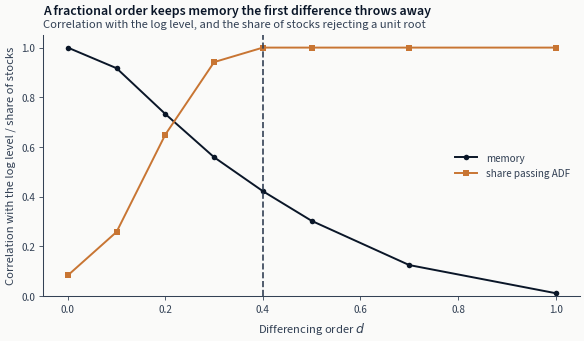

at d=0.4: memory 0.422, 100.0% of 120 sampled stocks reject a unit root | at d=1.0: memory 0.012, 100.0%
  the weight vector at d=0.4 truncates at 1458 lags


In [18]:
_chosen = ffd_grid.filter(pl.col("d") == FFD_D).row(0, named=True)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(ffd_grid["d"], ffd_grid["memory"], color=COLORS["blue"], marker="o", ms=4, label="memory")
ax.plot(
    ffd_grid["d"],
    ffd_grid["stationary_share"],
    color=COLORS["copper"],
    marker="s",
    ms=4,
    label="share passing ADF",
)
ax.axvline(FFD_D, color=COLORS["neutral"], ls="--", lw=1.2)
ax.set_xlabel("Differencing order $d$")
ax.set_ylabel("Correlation with the log level / share of stocks")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8, loc="center right")
add_message_title(
    ax,
    "A fractional order keeps memory the first difference throws away",
    subtitle="Correlation with the log level, and the share of stocks rejecting a unit root",
)
show_with_alt(
    fig,
    "Two curves against the differencing order on the horizontal axis. One falls "
    "monotonically from one at order zero to near zero at order one, the correlation the "
    "series keeps with its own log level. The other rises from near zero to one and then "
    "runs flat, the share of stocks whose unit root is rejected. A dashed vertical line "
    "marks the order chosen; it stands where the rising curve has just reached its ceiling "
    "and the falling curve still retains a substantial part of its height.",
)

print(
    f"at d={FFD_D}: memory {_chosen['memory']:.3f}, {_chosen['stationary_share']:.1%} of "
    f"{_chosen['n_symbols']} sampled stocks reject a unit root | "
    f"at d={ffd_grid['d'].max()}: memory "
    f"{ffd_grid.filter(pl.col('d') == ffd_grid['d'].max())['memory'][0]:.3f}, "
    f"{ffd_grid.filter(pl.col('d') == ffd_grid['d'].max())['stationary_share'][0]:.1%}"
)
print(
    f"  the weight vector at d={FFD_D} truncates at "
    f"{len(get_ffd_weights(FFD_D, threshold=FFD_THRESHOLD))} lags"
)

### Apply the transform to the panel

On the complete price series per stock, for the reason Section 1 states: the weight vector
reaches back hundreds of sessions, and on the screened frame those would be eligible rows
rather than sessions.

In [19]:
print("Computing fractional differencing features...")
ffd_df = apply_ffd_per_symbol(raw_df)
print(f"FFD features: {len(ffd_df):,} rows, {ffd_df['symbol'].n_unique()} symbols")

Computing fractional differencing features...


  FFD: 3193 symbols succeeded, 6 failed/skipped
FFD features: 14,498,518 rows, 3193 symbols


## 4. GARCH conditional volatility

This is the section the stage is really about. A GARCH conditional volatility is not a
function of a stock's past returns alone - it is a function of $(\mu, \omega, \alpha,
\beta)$, and those come from a maximum-likelihood fit over some window. Fit them once over
everything and every row's volatility knows the whole sample.

So each stock gets its own walk over its own return history:

1. Spend `GARCH_BURNIN` returns, which carry no value and pay for the first estimate.
2. Fit GARCH(1,1) by maximum likelihood on the returns up to the start of the next block.
3. Run the variance recursion forward with those coefficients held fixed, keep the block's
   own rows, and re-estimate on everything up to the start of the block after it.
4. Past the holdout boundary stop re-estimating and carry the last development coefficients
   forward, so no coefficient is estimated from a held-out session.

Every stock that clears the burn-in is fitted. A stock whose history is shorter takes the
market-level fit, which is the same walk over the cross-sectional median return, so every
emitted row carries a conditional volatility.

The returns handed to every fit come from the **complete** per-symbol series. A variance
recursion reads its input in order and treats consecutive elements as consecutive sessions;
feeding it the eligible rows only would splice the two sides of an ineligible spell
together and price the jump across it as one day's move.

In [20]:
# The specification comes from `setup.yaml::model_based.garch` rather than from this line,
# so the model a reader is told about and the model that is fitted are the same statement.
# These are `arch_model`'s own argument names and are passed through unchanged.
GARCH_KW = {
    "mean": str(_GARCH["mean"]),
    "vol": str(_GARCH["vol"]),
    "p": int(_GARCH["p"]),
    "o": int(_GARCH["o"]),
    "q": int(_GARCH["q"]),
    "dist": str(_GARCH["dist"]),
}

# `garch11_conditional_volatility` is a GARCH(1,1) recursion, optionally with the one
# asymmetry term. A declared parameter it cannot represent has to refuse here rather than be
# silently dropped on the way to the filter, which is the failure a declaration exists to
# prevent: the fit would estimate one model and the emitted column would carry another.
if GARCH_KW["vol"] != "GARCH" or GARCH_KW["p"] != 1 or GARCH_KW["q"] != 1:
    raise ValueError(
        f"model_based.garch declares vol={GARCH_KW['vol']} p={GARCH_KW['p']} q={GARCH_KW['q']}; "
        "the filter this notebook emits through is GARCH(1,1)"
    )
if GARCH_KW["o"] not in (0, 1):
    raise ValueError(f"model_based.garch declares o={GARCH_KW['o']}; the filter carries 0 or 1")
if GARCH_KW["mean"] not in ("Constant", "Zero"):
    raise ValueError(
        f"model_based.garch declares mean={GARCH_KW['mean']}; the filter subtracts a single "
        "constant, so only Constant and Zero are representable"
    )


def garch_walk(
    payload: tuple[str, FloatArray, int, list],
) -> tuple[str, FloatArray, list[dict]]:
    """One walk-forward GARCH per series: refit on schedule, filter forward, freeze at the
    holdout.

    Takes and returns percent returns' annualized conditional volatility in decimal, ``nan``
    over the burn-in and over any block whose fit did not converge, and one record per
    estimation so Section 4b can measure what re-estimating moved.
    """
    symbol, returns_pct, freeze_after, sessions = payload
    fits: list[dict] = []

    def fit(X_train: FloatArray) -> dict[str, float]:
        result = arch_model(X_train[:, 0], **GARCH_KW).fit(disp="off", show_warning=False)
        # `arch` returns a result whatever the optimizer did and only warns, which
        # `show_warning=False` then swallows. A parameter vector the search never converged
        # on is not an estimate, so it is rejected here and `on_fit_error="skip"` leaves the
        # block empty - the coverage table in Section 5 is where that cost shows up.
        if result.convergence_flag != 0:
            raise RuntimeError(
                f"the variance model did not converge on {symbol}: scipy flag "
                f"{result.convergence_flag}"
            )
        coefficients = {
            # A zero-mean specification estimates no `mu` at all, so the parameter vector has
            # no such entry to read; the filter still subtracts one and it is zero.
            "mu": float(result.params["mu"]) if GARCH_KW["mean"] == "Constant" else 0.0,
            "omega": float(result.params["omega"]),
            "alpha": float(result.params["alpha[1]"]),
            # The leverage coefficient under `o=1`, zero under the symmetric model. Read from
            # the fit rather than assumed, so a declared `o` reaches the emitted values.
            "gamma": float(result.params["gamma[1]"]) if GARCH_KW["o"] else 0.0,
            "beta": float(result.params["beta[1]"]),
            # The value that seeds the recursion, computed by `arch` from the ESTIMATION
            # window's residuals and nothing else. It has to be produced here, where only
            # training returns are in scope: the array `apply` receives runs to the end of
            # the block being emitted, so a seed derived there would read the block's own
            # sessions.
            "backcast": float(result.model.volatility.backcast(np.asarray(result.resid))),
        }
        fits.append({"symbol": symbol, "fit_end": len(X_train), **coefficients})
        return coefficients

    def apply(coefficients: dict[str, float], X_prefix: FloatArray) -> FloatArray:
        # `garch11_conditional_volatility` rather than the fitted result object's own
        # `conditional_volatility`, which is what `arch_model(...).fix(params)` returns.
        # `arch` re-derives the residuals, the backcast that seeds the recursion and the
        # variance bounds from whatever array it is handed, and the array here runs to the
        # end of the block being emitted - so an emitted value would move when the block's
        # own later returns arrived. The helper takes all three from `fit`, where only
        # earlier returns are in scope.
        #
        # The recursion runs on percent returns; restore decimal and annualize.
        sigma = garch11_conditional_volatility(X_prefix[:, 0], **coefficients)
        return sigma * np.sqrt(252) / 100

    values = walk_forward_feature(
        returns_pct.reshape(-1, 1),
        timestamps=sessions,
        burnin=GARCH_BURNIN,
        refit_every=GARCH_REFIT_EVERY,
        fit=fit,
        apply=apply,
        n_features=1,
        freeze_after=freeze_after,
        # A single window of returns that will not converge leaves that block null and the
        # walk carries on. Raising would discard a stock's whole series over one window.
        on_fit_error="skip",
    )
    return symbol, values[:, 0], fits

Each stock is an independent walk, so they are spread across processes. Within one walk the
blocks are sequential - each refit reads everything before it - and each `arch_model` fit is
single-threaded, so parallelising anywhere else buys nothing. A fork context is named rather
than left to the default, because Python 3.14 defaults to forkserver, which re-imports the
parent module and cannot reach a function defined in a notebook kernel.

In [21]:
returns_panel = (
    raw_df.select("symbol", "timestamp", "returns")
    .drop_nulls(subset=["returns"])
    .sort(["symbol", "timestamp"])
    .with_columns(ret=pl.col("returns") * 100)
)
symbol_sessions = {
    symbol: group["timestamp"].to_list()
    for (symbol,), group in returns_panel.group_by(["symbol"], maintain_order=True)
}
symbol_returns = {
    symbol: group["ret"].to_numpy()
    for (symbol,), group in returns_panel.group_by(["symbol"], maintain_order=True)
}

garch_symbols = sorted(symbol_returns)
if MAX_SYMBOLS > 0:
    # `top_entities` rather than the alphabetically first names: it is the one rule every
    # loader's `apply_max_symbols` and 05's own reduction reach, so a reduced run here fits
    # volatility models for the same stocks the reduced 05 goes on to score. Taking the
    # alphabetical head instead left every scored stock on the market-level broadcast, which
    # runs clean and measures something else.
    garch_symbols = sorted(top_entities(returns_panel, MAX_SYMBOLS, "symbol"))

payloads, n_too_short = [], 0
for symbol in garch_symbols:
    sessions = symbol_sessions[symbol]
    if len(sessions) <= GARCH_BURNIN:
        n_too_short += 1
        continue
    freeze_after = sum(1 for d in sessions if d < holdout_start)
    payloads.append((symbol, symbol_returns[symbol], freeze_after, sessions))

print(
    f"{len(payloads):,} of {len(garch_symbols):,} stocks carry more than the "
    f"{GARCH_BURNIN}-session burn-in and are fitted; the other {n_too_short:,} take the "
    "market-level volatility"
)
_scheduled_blocks = sum(
    len(refit_boundaries(len(returns), GARCH_BURNIN, GARCH_REFIT_EVERY))
    for _, returns, _, _ in payloads
)
print(f"  {_scheduled_blocks:,} blocks on the schedule", flush=True)

# `process_cpu_count` rather than `cpu_count`: it reports the cores this process may
# actually run on, so an affinity mask or a cgroup quota on a shared machine reduces the
# pool instead of being ignored. `cpu_count` reports the hardware and would take every
# core whatever the run was given.
workers = max(1, min(len(payloads), (os.process_cpu_count() or 2) - 1))
print(f"  fitting across {workers} processes", flush=True)

# `payloads` carries the arrays and the session lists the fits read, so the frame they were
# taken from is dead here. It is deleted before the fork rather than after it, because what
# the children inherit is whatever is live at the moment the fork happens: 0.32 GB.
del returns_panel

# A forked child shares the parent's heap copy-on-write, and the pages stay shared until
# something writes to them. Python's cyclic collector writes to all of them: a collection
# traverses every tracked object and updates a header field, which faults in a private copy
# of the page that object sits on - so a child that never reads the parent's data still
# copies part of it, once per child, for nothing. `freeze` moves what is already allocated
# into a permanent generation the collector does not traverse.
#
# The bound on what this saves is the *Python-object* heap, not the frames: a polars frame's
# values live in Arrow buffers the collector does not track, so the frames above cost one
# tracked object each however many rows they hold. `symbol_sessions` is the exception and is
# what makes it worth doing here - 14.5M `date` objects in per-symbol lists. Measured on a
# heap of that shape with 23 children on 2026-09-10: 0.66 GB of tree Pss frozen, against
# 0.77-1.06 GB over three unfrozen runs, which also spread by when the collector happened to
# fire.
gc.collect()
gc.freeze()
try:
    with ProcessPoolExecutor(
        max_workers=workers, mp_context=multiprocessing.get_context("fork")
    ) as pool:
        walked = list(pool.map(garch_walk, payloads, chunksize=8))
finally:
    gc.unfreeze()

garch_df = (
    pl.concat(
        [
            pl.DataFrame(
                {
                    "symbol": [symbol] * len(values),
                    "timestamp": symbol_sessions[symbol],
                    "garch_cond_vol": values,
                }
            )
            for symbol, values, _ in walked
        ]
    )
    # Same `nan`-to-null conversion as the regime columns, and for the same reason: the
    # burn-in and any block that did not converge are marked with `np.nan`, which polars
    # keeps as a float value rather than a null.
    .with_columns(pl.col("garch_cond_vol").fill_nan(None))
    .drop_nulls(subset=["garch_cond_vol"])
)
garch_fits = [record for _, _, fits in walked for record in fits]
garch_params = pl.DataFrame(garch_fits).with_columns(
    pl.Series(
        "fit_end_session",
        [symbol_sessions[record["symbol"]][record["fit_end"] - 1] for record in garch_fits],
    )
)

# Both frames above are built, so the per-symbol arrays the pool returned are dead.
del walked, garch_fits, payloads, symbol_returns, symbol_sessions

print(
    f"Per-stock conditional volatility: {garch_df.height:,} rows on "
    f"{garch_df['symbol'].n_unique():,} stocks, from {garch_params.height:,} estimations"
)
assert garch_params["fit_end_session"].max() < holdout_start, (
    f"a volatility model read sessions through {garch_params['fit_end_session'].max()}, "
    f"inside the holdout opening {holdout_start}"
)
print(f"  every fit ended before {holdout_start}")

3,160 of 3,199 stocks carry more than the 504-session burn-in and are fitted; the other 39 take the market-level volatility
  205,949 blocks on the schedule


  fitting across 23 processes


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.91e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.698e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.529e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


...

.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.541e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.482e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.427e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.376e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Per-stock conditional volatility: 12,821,566 rows on 3,077 stocks, from 182,743 estimations
  every fit ended before 2016-01-01


The market-level series takes the same walk. It is what a stock too short to pay the
burn-in carries, and it is a feature in its own right: the volatility of the panel's centre
is a market-level quantity every stock on a session shares.

In [22]:
_market_freeze_after = int(sum(1 for d in dates if d < holdout_start))
_, mkt_values, mkt_fits = garch_walk(("__market__", market_ret * 100, _market_freeze_after, dates))
mkt_garch_df = (
    pl.DataFrame({"timestamp": dates, "mkt_garch_vol": mkt_values})
    .with_columns(pl.col("mkt_garch_vol").fill_nan(None))
    .drop_nulls(subset=["mkt_garch_vol"])
)
print(
    f"Market-level conditional volatility: {mkt_garch_df.height:,} sessions from "
    f"{len(mkt_fits)} estimations, first value {mkt_garch_df['timestamp'].min()}"
)

Market-level conditional volatility: 6,590 sessions from 96 estimations, first value 1992-01-28


## 4b. What re-estimating moves

The schedule costs a fit per series per block, and the question it raises is whether the
parameters move enough to be worth it. Two of the three transforms have parameters to
track: the GARCH persistence $\alpha + \beta$, which says how long a volatility shock takes
to decay, and the separation between the two Wasserstein centroids, which says how far
apart the two regimes the clustering found actually are. FFD has none, by construction.

A parameter path that is flat says the cadence bought nothing beyond making the feature
causal, and one fit would have served for the values; a path that swings says the transform
is chasing a moving target, and the reader should carry that into how much weight the
feature deserves. The two answers differ here, which is the point of measuring rather than
assuming: the volatility persistence returns to nearly the same value at almost every
estimate, while the gap between the two regime centroids spans close to a factor of four.

**Both paths are drawn for one series each** - the market-level volatility model and the
market-level clustering - so that what moves is the parameter and not the composition of
the panel. A per-stock path pooled across the cross-section would move for two reasons at
once: the coefficients change, and so does which stocks were long enough to be fitted that
year. The spread across stocks is reported below the figure as a number rather than drawn
as a path, for the same reason.

The figure is also the schedule made visible. Each marker sits on the last session its fit
read; the shaded band on the left is the burn-in, which carries no value; and
re-estimation stops at the dashed rule, past which the last development estimate is carried
forward.

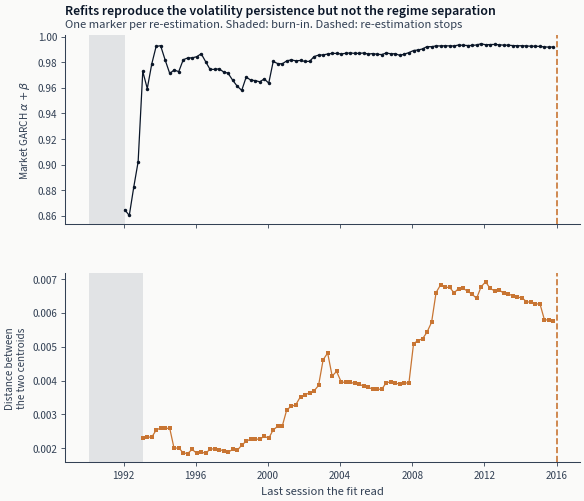

In [23]:
_mkt_params = pl.DataFrame(mkt_fits).with_columns(
    pl.Series("fit_end_session", [dates[record["fit_end"] - 1] for record in mkt_fits]),
    # alpha + gamma/2 + beta. `gamma` is the leverage coefficient, zero under the symmetric
    # specification this case study declares, and the halving is the asymmetry's contribution
    # under symmetric shocks - so this reads alpha + beta here and stays the persistence if
    # `model_based.garch.o` is ever declared as 1.
    (pl.col("alpha") + pl.col("gamma") / 2 + pl.col("beta")).alias("persistence"),
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=FIGSIZE["dual_v"], sharex=True, gridspec_kw={"hspace": 0.18}
)
ax1.plot(
    _mkt_params["fit_end_session"],
    _mkt_params["persistence"],
    color=COLORS["blue"],
    marker="o",
    ms=2.5,
    lw=0.9,
)
ax1.set_ylabel(r"Market GARCH $\alpha+\beta$", fontsize=8)
ax2.plot(
    regime_fit_df["fit_end_session"],
    regime_fit_df["centroid_separation"],
    color=COLORS["copper"],
    marker="s",
    ms=2.5,
    lw=0.9,
)
ax2.set_ylabel("Distance between\nthe two centroids", fontsize=8)
ax2.set_xlabel("Last session the fit read")
for ax, burnin_end in (
    (ax1, dates[min(GARCH_BURNIN, len(dates) - 1)]),
    (ax2, dates[min(REGIME_BURNIN, len(dates) - 1)]),
):
    ax.axvspan(dates[0], burnin_end, color=COLORS["neutral"], alpha=0.12, lw=0)
    ax.axvline(holdout_start, color=COLORS["copper"], ls="--", lw=1.2)
add_message_title(
    ax1,
    "Refits reproduce the volatility persistence but not the regime separation",
    subtitle="One marker per re-estimation. Shaded: burn-in. Dashed: re-estimation stops",
)
show_with_alt(
    fig,
    "Two stacked panels against the date of each re-estimation, sharing a date axis. The "
    "upper panel plots the market volatility model's fitted persistence: a dense line of "
    "markers sitting close to the top of the axis for almost the whole sample, with a few "
    "sharp dips away from it. The lower panel plots the distance between the two regime "
    "centroids, which moves over a range of about four to one, rising into the early 2000s "
    "and again around 2009 and falling back between. A shaded band at the left of each panel "
    "marks the burn-in and a dashed vertical line marks where re-estimation stops.",
)

**How far the fitted parameters move as the schedule advances.** The first two ranges are
over the market-level series each panel draws. The third is the spread across stocks,
pooled over every per-stock estimation: it describes how differently two stocks behave
rather than how one stock's coefficient moves, and the two are not the same quantity.

In [24]:
print(
    f"Market GARCH persistence over {_mkt_params.height} estimations: "
    f"{_mkt_params['persistence'].min():.4f} to {_mkt_params['persistence'].max():.4f}, "
    f"median {_mkt_params['persistence'].median():.4f}"
)
print(
    f"Distance between the two Wasserstein centroids over {regime_fit_df.height} "
    f"estimations: {regime_fit_df['centroid_separation'].min():.5f} to "
    f"{regime_fit_df['centroid_separation'].max():.5f}"
)
_stock_persistence = (
    garch_params["alpha"] + garch_params["gamma"] / 2 + garch_params["beta"]
).drop_nulls()
print(
    f"Per-stock persistence over {garch_params.height:,} estimations on "
    f"{garch_params['symbol'].n_unique():,} stocks: median {_stock_persistence.median():.4f}, "
    f"interquartile {_stock_persistence.quantile(0.25):.4f} to "
    f"{_stock_persistence.quantile(0.75):.4f}"
)

Market GARCH persistence over 96 estimations: 0.8602 to 0.9945, median 0.9865
Distance between the two Wasserstein centroids over 92 estimations: 0.00184 to 0.00692
Per-stock persistence over 182,743 estimations on 3,077 stocks: median 0.9841, interquartile 0.9364 to 0.9954


## 5. Assemble the panel

One frame, keyed on the stock and the session. It starts from the eligible symbol-dates
and the three transforms are joined onto it: the clustering and the market-level volatility
are one value per session, so they broadcast across every stock trading that session, and
the fractional differences and the per-stock volatility join on both keys.

A stock too short to have paid the volatility burn-in carries the market-level value in
place of its own, so no emitted row is left without a conditional volatility.

In [25]:
for _name, _frame in (("regime", wass_df), ("ffd", ffd_df), ("garch", garch_df)):
    assert _frame.height > 0, (
        f"the {_name} transform emitted nothing, so the column it contributes would be joined "
        "as an empty frame rather than raise"
    )

skeleton = df.select(["symbol", "timestamp"]).unique()

temporal = (
    skeleton.join(wass_df, on="timestamp", how="left")
    .join(ffd_df, on=["symbol", "timestamp"], how="left")
    .join(garch_df, on=["symbol", "timestamp"], how="left")
    .join(mkt_garch_df, on="timestamp", how="left")
    .with_columns(
        pl.coalesce(pl.col("garch_cond_vol"), pl.col("mkt_garch_vol")).alias("garch_cond_vol")
    )
    .sort(["symbol", "timestamp"])
)

temporal_feature_cols = [c for c in temporal.columns if c not in ("symbol", "timestamp")]
n_temporal_features = len(temporal_feature_cols)

# Every transform is joined onto one frame, so the three that fed the join are dead, and so
# is the eligible panel the skeleton was taken from. `garch_df` is the exception: Section 6
# counts the stocks it covered when it records the provenance.
del skeleton, wass_df, ffd_df, mkt_garch_df, df

A missing value has to be a null and not a NaN. `ffdiff` returns a float NaN where the log
price it is handed is not finite, and Polars does not treat that as missing: `drop_nulls`
keeps the row, and every summary that reaches it returns NaN rather than skipping it -
including the one printed immediately below. So the conversion happens here rather than at
the write. `03_financial_features` converts its oscillators' NaN for the same reason.

In [26]:
_nan_columns = {
    c: int(temporal[c].is_nan().sum())
    for c in temporal_feature_cols
    if temporal.schema[c] in (pl.Float32, pl.Float64) and temporal[c].is_nan().any()
}
if _nan_columns:
    temporal = temporal.with_columns(pl.col(c).fill_nan(None) for c in _nan_columns)
print(
    f"NaN converted to null in {len(_nan_columns)} of {n_temporal_features} features, "
    f"{sum(_nan_columns.values()):,} values: {sorted(_nan_columns)}"
)
print(
    f"\n{n_temporal_features} features on {temporal.height:,} rows, "
    f"{temporal['symbol'].n_unique():,} stocks, {temporal['timestamp'].n_unique():,} sessions"
)

NaN converted to null in 0 of 9 features, 0 values: []

9 features on 9,978,112 rows, 3,178 stocks, 7,094 sessions


### What the assembled panel holds

A fitted feature legitimately starts after the estimation window that produced it, so the
leading gap is reported rather than asserted away. It is worth reporting because it is
otherwise invisible downstream: `sequence_dataset` turns a null feature into `0.0`, which
after normalization is the feature's mean, so a row missing a feature is fitted as an
average observation and nothing raises. The same geometry goes into the digest sidecar, so
a later stage can compare against it instead of measuring it again by hand.

`first value`, `rows with a value` and `coverage` count every emitted row, holdout sessions
included: the model stages read those rows to score the holdout once, so a column with no
value there has no value in something they will read.

`mean` and `std` summarize the values a feature takes, and on holdout sessions those are
values this stage may not read. Both are therefore taken over the development history
alone.

In [27]:
_development = temporal.filter(pl.col("timestamp") < pl.lit(holdout_start).cast(pl.Date))
display(
    pl.DataFrame(
        [
            {
                "feature": c,
                "first value": temporal.filter(pl.col(c).is_not_null())["timestamp"].min(),
                "rows with a value": temporal[c].drop_nulls().len(),
                "coverage": temporal[c].drop_nulls().len() / temporal.height,
                "mean (development)": _development[c].drop_nulls().mean(),
                "std (development)": _development[c].drop_nulls().std(),
            }
            for c in temporal_feature_cols
        ]
    )
)
_scored = temporal.filter(in_validation_windows())
print(
    "Coverage over the sessions the folds validate on, which is what a model actually reads: "
    + ", ".join(
        f"{c} {_scored[c].drop_nulls().len() / _scored.height:.1%}" for c in temporal_feature_cols
    )
)

feature,first value,rows with a value,coverage,mean (development),std (development)
str,date,i64,f64,f64,f64
"""wass_cluster""",1993-01-26,9683822,0.970506,0.414509,0.492637
"""wass_dist_min""",1993-01-26,9683822,0.970506,0.00338,0.003922
"""wass_dist_max""",1993-01-26,9683822,0.970506,0.005912,0.004764
"""wass_dist_ratio""",1993-01-26,9683822,0.970506,0.561305,0.216737
"""wass_tail_div""",1993-01-26,9683822,0.970506,0.000096,0.004129
"""ffd_log_price""",1990-01-30,9977957,0.999984,0.136048,0.079362
"""ffd_log_volume""",1990-01-30,9977957,0.999984,0.565148,0.563127
"""garch_cond_vol""",1991-12-31,9803326,0.982483,0.416784,0.811197
"""mkt_garch_vol""",1992-01-28,9796673,0.981816,0.163292,0.096714


Coverage over the sessions the folds validate on, which is what a model actually reads: wass_cluster 100.0%, wass_dist_min 100.0%, wass_dist_max 100.0%, wass_dist_ratio 100.0%, wass_tail_div 100.0%, ffd_log_price 100.0%, ffd_log_volume 100.0%, garch_cond_vol 100.0%, mkt_garch_vol 100.0%


## 6. Write the artifact

The panel key is `(symbol, timestamp)`. A stock-date carries one value, because what bounds
every estimate on this page is the schedule rather than a fold, and the schedule does not
depend on which fold later selects the row. A downstream join is a left join on those two
columns and multiplies nothing.

The checks run before the write, and each of them is a claim the file would otherwise make
silently: that the columns present are exactly the ones the three transforms said they
would emit, that no missing value slipped through as a NaN, that the two-column key is
unique, that every emitted row is on a symbol-date the eligibility screen kept, and that
nothing reaches past the last holdout session. `write_model_based` adds its own: no null
key, no duplicate, and no declared feature column that is empty.

Beside the parquet the write also leaves a small companion file, the **digest sidecar**. A
digest is a hash of the values in a frame, so two files with the same digest hold the same
numbers. The sidecar's job is to let anything reading this artifact establish what it was
built from, without re-running anything. It records the digest of the values written here,
how many rows they occupy, which columns identify a row, which notebook wrote them, the
estimation schedule each model ran on, and the digest of the price panel they were computed
from. That last entry is what Section 1 compared against at the top of this notebook, and
it is what lets a model notebook confirm that the features and the labels it is joining
came from one download. [`02_labels`](02_labels.ipynb) and
[`03_financial_features`](03_financial_features.ipynb) leave the same record beside their
own artifacts.

In [28]:
EMITTED_FEATURES = [
    "wass_cluster",
    "wass_dist_min",
    "wass_dist_max",
    "wass_dist_ratio",
    "wass_tail_div",
    "ffd_log_price",
    "ffd_log_volume",
    "garch_cond_vol",
    "mkt_garch_vol",
]
assert sorted(temporal_feature_cols) == sorted(EMITTED_FEATURES), (
    f"emitted {sorted(temporal_feature_cols)} against declared {sorted(EMITTED_FEATURES)}"
)

# No NaN reaches the artifact. Converted in Section 5, checked here.
_still_nan = [
    c
    for c in temporal_feature_cols
    if temporal.schema[c] in (pl.Float32, pl.Float64) and temporal[c].is_nan().any()
]
assert not _still_nan, f"features reaching the artifact with NaN: {_still_nan}"

KEY_COLS = ["symbol", "timestamp"]
assert temporal.select(KEY_COLS).n_unique() == temporal.height, (
    f"{temporal.height - temporal.select(KEY_COLS).n_unique()} duplicate rows on {KEY_COLS}"
)
assert "fold" not in temporal.columns, (
    "a fold column reached the panel; the schedule is what bounds an estimate here"
)
assert temporal["timestamp"].max() <= holdout_end, (
    f"the panel reaches {temporal['timestamp'].max()}, past the holdout's last session "
    f"{holdout_end}, which no stage of this case study reads"
)
print(f"{temporal.height:,} rows, one per eligible stock-session, none past {holdout_end}")

9,978,112 rows, one per eligible stock-session, none past 2018-03-31


In [29]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
output_path = FEATURES_DIR / "model_based.parquet"
record = write_model_based(
    temporal,
    output_path,
    keys=KEY_COLS,
    feature_columns=temporal_feature_cols,
    time_column="timestamp",
    fold_column=None,
    written_by=f"case_studies/{CASE_STUDY_ID}/04_model_based_features.py",
    inputs={"market_data": MARKET_DATA_DIGEST},
    metadata={
        "regime": {
            "burnin": REGIME_BURNIN,
            "refit_every": REGIME_REFIT_EVERY,
            "n_clusters": N_CLUSTERS,
            "window": WASSERSTEIN_WINDOW,
            "overlap": WASSERSTEIN_OVERLAP,
            "n_estimations": regime_fit_df.height,
        },
        "garch": {
            "burnin": GARCH_BURNIN,
            "refit_every": GARCH_REFIT_EVERY,
            "n_estimations": garch_params.height,
            "n_symbols": int(garch_df["symbol"].n_unique()),
        },
        "freeze_after": HOLDOUT_START,
    },
)
print(f"Saved {n_temporal_features} features to {display_path(output_path)}")
print(f"model_based.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

Saved 9 features to case_studies/us_equities_panel/features/model_based.parquet
model_based.parquet: 9,978,112 rows, digest f6f40ca369d56f9b


## 7. What each column ranks on its own

The **information coefficient** of a column is the rank correlation, across the stocks
scored on one date, between the value the column gives each stock and the return that stock
actually went on to earn. One correlation per date gives a series, and the series is what is
summarized below.

What it measures here is each column **on its own**, which is not the same question as what
each column adds. A column can rank the cross-section well and still add nothing a model did
not already have from the stage-03 matrix, or rank it barely at all and still matter once a
model conditions on it. Answering the second question means fitting with and without these
columns on the same folds, which needs both matrices and a model, so it belongs to
[`05_evaluation`](05_evaluation.ipynb). This section neither answers it nor selects anything.

**Scored sessions only.** The frame below is the union of the cross-validation folds'
validation spans, which is the set of sessions a model in the later stages is validated on.
Nothing here is restricted to keep a fit honest - the schedule already does that, and every
row of the artifact carries parameters estimated before it - but a marginal IC measured
over sessions a model never sees says nothing about what that model receives.

**The boundary is where the label resolves, not where it is observed.** A row observed on
the last validation session of the last fold resolves `LABEL_HORIZON` sessions later, and if
that lands on or after `holdout_start` the row has read a held-out outcome. The usable
boundary is therefore the last session whose forward window closes before the holdout opens,
which is derived below from the panel's own calendar rather than typed.

**Chronologically ordered.** `cross_sectional_ic_series` sorts the dates it returns.
Feeding a Newey-West correction a series assembled in partition-scan order computes the
lag structure over an arbitrary permutation of time, and the resulting standard error is
not merely wrong but unstable between runs.

**Two corrections, kept apart.** Newey-West prices the IC series' own persistence into each
feature's t-statistic; Benjamini-Hochberg prices the fact that several features are tested
at once. Neither substitutes for the other.

**And only the features a cross-sectional statistic can measure.** Most of what this
notebook emits is market-level: the Wasserstein features describe the panel's centre on a
date, and `mkt_garch_vol` describes its volatility, so every stock carries the same value
on that date. An information coefficient is a correlation *across* the cross-section, and a
column with no cross-sectional variation has no correlation with anything in it - not a
small one, an undefined one. Scoring such a column here returns a number, and the number is
an artifact of how the tie is broken rather than a statement about the feature. The cell
below classifies the emitted columns by counting distinct values within a date and scores
only those that vary, and the ones it sets aside are set aside by measurement rather than
by a list somebody kept up to date.

Setting them aside says nothing about their worth. A daily regime state can matter to a
cross-sectional ranker through what it interacts with - momentum conditioned on the regime
is a different signal from momentum - and it can matter to a timing overlay. Both are
questions about a fitted model, so both belong downstream; neither is answerable with the
statistic this section computes.

The endpoint of a label is the `LABEL_HORIZON`-th next session in the stock's own series,
read off the complete price frame so that it is the next session and not the next session on
which the stock happened to still be eligible - a later date, and one decided by what
happened after the decision was made.

Two assertions carry the section. The first is that the validation windows do not overlap,
because the correlation helper self-joins on the date and a session reaching the frame
twice would quietly multiply the cross-section rather than raise. The second is that no
scored row's label resolves inside the holdout.

In [30]:
_label_df = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
label_col = PRIMARY_LABEL

_label_end = raw_df.select(
    "symbol",
    "timestamp",
    pl.col("timestamp").shift(-LABEL_HORIZON).over("symbol").alias("_label_end"),
)

_spans = sorted((f["test_start"], f["test_end"]) for f in folds)
for (_, earlier_end), (later_start, _) in zip(_spans, _spans[1:]):
    assert earlier_end < later_start, (
        f"validation windows overlap at {later_start}; a session would be scored twice"
    )

_val_rows = temporal.filter(in_validation_windows())

eval_df = (
    _val_rows.join(_label_df, on=["symbol", "timestamp"], how="inner")
    .join(_label_end, on=["symbol", "timestamp"], how="left")
    .filter(pl.col("_label_end") < holdout_start)
    .drop("_label_end")
)
assert eval_df["timestamp"].max() < holdout_start, "a scored row resolves inside the holdout"

print(f"Scoring {len(temporal_feature_cols)} columns against {label_col}")
print(
    f"  {eval_df.height:,} scored rows over {eval_df['timestamp'].n_unique():,} sessions, "
    f"the last resolving before {holdout_start}"
)

Scoring 9 columns against fwd_ret_1d
  7,171,450 scored rows over 4,031 sessions, the last resolving before 2016-01-01


The narrowest cross-section a correlation is computed over is half the median date's, rather
than a fixed count, for the reason `02_labels` gives: a rank correlation over a handful of
names is mostly noise, and a fixed threshold means something different on a panel of a
hundred stocks than on one of a thousand. Dates below it contribute no point to the series.

In [31]:
_min_obs = int(eval_df.group_by("timestamp").len()["len"].median() // 2)
print(f"A date is scored when at least {_min_obs:,} stocks are ranked on it")

A date is scored when at least 915 stocks are ranked on it


Which columns vary across a cross-section is measured, not declared. A feature whose
median date carries a single distinct value is market-level and is set aside; the count
for each is printed, so a column that is *nearly* constant - a handful of distinct values
across a cross-section of hundreds - is visible as the partial thing it is rather than
passing as cross-sectional.

In [32]:
_variation = (
    eval_df.group_by("timestamp")
    .agg(pl.col(c).n_unique().alias(c) for c in temporal_feature_cols)
    .select(pl.col(c).median().alias(c) for c in temporal_feature_cols)
    .row(0, named=True)
)
CROSS_SECTIONAL = [c for c in temporal_feature_cols if _variation[c] > 1]
MARKET_LEVEL = [c for c in temporal_feature_cols if _variation[c] <= 1]

display(
    pl.DataFrame(
        [
            {
                "feature": c,
                "distinct_values_on_median_date": int(_variation[c]),
                "scored_below": _variation[c] > 1,
            }
            for c in temporal_feature_cols
        ]
    )
)
assert CROSS_SECTIONAL, "no emitted feature varies across the cross-section"

feature,distinct_values_on_median_date,scored_below
str,i64,bool
"""wass_cluster""",1,false
"""wass_dist_min""",1,false
"""wass_dist_max""",1,false
"""wass_dist_ratio""",1,false
"""wass_tail_div""",1,false
"""ffd_log_price""",1830,true
"""ffd_log_volume""",1821,true
"""garch_cond_vol""",1734,true
"""mkt_garch_vol""",1,false


In [33]:
ic_rows = []
for feat in CROSS_SECTIONAL:
    _ic = cross_sectional_ic_series(
        eval_df,
        eval_df,
        pred_col=feat,
        ret_col=label_col,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=_min_obs,
    ).drop_nulls("ic")
    if _ic.height < 20:
        continue
    stats = compute_ic_hac_stats(_ic, ic_col="ic", label_horizon=LABEL_HORIZON)
    ic_rows.append(
        {
            "feature": feat,
            "n_dates": _ic.height,
            "ic_mean": stats["mean_ic"],
            "hac_se": stats["hac_se"],
            "hac_tstat": stats["t_stat"],
            "p_value": stats["p_value"],
        }
    )

temporal_ic = pl.DataFrame(ic_rows)
assert temporal_ic.height > 0, "no temporal feature carried enough scored dates to compute an IC"

_fdr = benjamini_hochberg_fdr(
    temporal_ic["p_value"].to_list(), alpha=FDR_ALPHA, return_details=True
)
temporal_ic = temporal_ic.with_columns(
    pl.Series("adjusted_p", list(_fdr["adjusted_p_values"])),
    pl.Series("significant_fdr05", list(_fdr["rejected"])),
).sort(pl.col("ic_mean").abs(), descending=True)

**What each column ranks on its own, over the validation rows.** The count set aside is the
market-level columns the statistic cannot reach; of the rest, the first figure is how many
clear the 5% level on their own t-statistic and the second how many survive the
Benjamini-Hochberg correction for testing several columns at once.

In [34]:
print(
    f"{temporal_ic.height} of {len(temporal_feature_cols)} columns scored "
    f"({len(MARKET_LEVEL)} set aside as market-level); "
    f"{int((temporal_ic['p_value'] < FDR_ALPHA).sum())} significant on their own and "
    f"{int(_fdr['n_rejected'])} after Benjamini-Hochberg"
)
display(temporal_ic.select("feature", "n_dates", "ic_mean", "hac_tstat", "significant_fdr05"))

3 of 9 columns scored (6 set aside as market-level); 3 significant on their own and 3 after Benjamini-Hochberg


feature,n_dates,ic_mean,hac_tstat,significant_fdr05
str,i64,f64,f64,bool
"""ffd_log_volume""",4031,0.014704,16.730969,true
"""ffd_log_price""",4031,-0.013116,-5.846112,true
"""garch_cond_vol""",4031,-0.012316,-4.701686,true


The bars are signed, because a column the panel ranks one way and a column it ranks the
other are different signals and a sorted magnitude hides that. The whisker is
$\pm2$ Newey-West standard errors, and the fill marks whether Benjamini-Hochberg still
rejects the null for that column. Only the columns that vary across a cross-section appear,
and the table above names the ones set aside; the comparison against the stage-03 features
is deferred to [`05_evaluation`](05_evaluation.ipynb), which scores both matrices on one
frame.

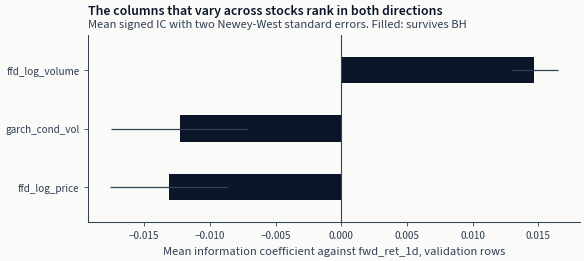

In [35]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
_order = temporal_ic.sort("ic_mean")
_ypos = np.arange(_order.height)
ax.barh(
    _ypos,
    _order["ic_mean"],
    xerr=2 * _order["hac_se"].to_numpy(),
    color=[
        COLORS["blue"] if s else COLORS["silver_muted"]
        for s in _order["significant_fdr05"].to_list()
    ],
    error_kw=dict(ecolor=COLORS["neutral"], lw=0.9),
    height=0.45,
)
ax.set_yticks(_ypos)
ax.set_yticklabels(_order["feature"].to_list(), fontsize=8)
ax.set_ylim(-0.6, _order.height - 0.4)
ax.axvline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel(f"Mean information coefficient against {label_col}, validation rows")
add_message_title(
    ax,
    "The columns that vary across stocks rank in both directions",
    subtitle="Mean signed IC with two Newey-West standard errors. Filled: survives BH",
)
show_with_alt(
    fig,
    "One horizontal bar per scored feature, giving its mean information coefficient against "
    "the one-day forward return over the scored sessions, with a whisker of two Newey-West "
    "standard errors and a vertical line at zero. Three bars appear: the fractionally "
    "differenced volume extends to the right of zero and the fractionally differenced price "
    "and the conditional volatility extend to the left by a similar distance. All three are "
    "filled solid, marking them as surviving the false-discovery correction, and no whisker "
    "crosses the zero line.",
)

## Key takeaways

1. **A fitted feature has two channels into the future, and closing one is not closing
   both.** Which observations a value is computed from is one; which observations its
   parameters were estimated from is the other. Running the recursion forward closes the
   first. Only a schedule that fits on a strict prefix of the block it emits closes the
   second, and it closes it at every session rather than after some window has passed.
2. **A schedule bounds an estimate; a fold selects rows.** Because the schedule does not
   depend on which fold later reads a row, the artifact carries one value per stock-session
   and joins on `(symbol, timestamp)` alone. The folds are still resolved here, from the same
   frame the model stages resolve them from, but only to say which sessions Section 7 scores.
3. **Count windows in sessions, and get sessions from the exchange calendar.** An archive
   carries stray prints on dates no market was held. A rolling average, a difference
   convolution and a variance recursion all read their input in order and treat consecutive
   elements as consecutive sessions, so a stray row silently widens every window that spans
   it. Screening on the calendar first is what makes "twenty-one sessions" mean that.
4. **A library's fitted result object is not necessarily causal, even when the parameters
   are.** `arch_model(...).fix(params)` runs the recursion with the coefficients it is
   given, and derives the residuals, the seeding backcast and the variance bounds from
   whatever array it is handed. Handed an array that reaches the end of the block being
   emitted, it reads that block's own returns into values dated before them. The seed and
   the bounds have to be produced where only earlier returns are in scope and travel with
   the coefficients.
5. **Stop re-estimating before the holdout, and say why the values may still be emitted.**
   These transforms read prices and never labels, so parameters fitted entirely on
   development sessions may be run forward to produce values *for* holdout sessions, which
   the model stages need to score the holdout once. What is forbidden is an estimate that
   reads a held-out bar, and `freeze_after` is what rules it out.
6. **Measure the trade a default encodes.** The differencing order is not searched and does
   not have to be, but the memory it keeps and the stationarity it buys are measurable in a
   few lines and were worth measuring rather than quoting.
7. **Score on the sessions a model is validated on, in time order, and call the result what
   it is.** A per-date IC series in partition order gives a Newey-West standard error
   computed over a permutation of time; the multiplicity correction is a separate quantity
   from the autocorrelation one; and a per-feature IC is marginal, so it cannot answer the
   incremental question however many corrections it carries.
8. **Check that the statistic can reach the column before reporting it.** Most of what a
   market-level transform emits is constant within a session, and a rank correlation across
   a cross-section of identical values is undefined rather than zero. A correlation helper
   handed such a column still returns a number, decided by how it breaks the ties, so which
   columns to score is measured from the data rather than taken from a list, and the ones it
   cannot reach are named and set aside instead of ranked.

### Known limitations

- Most of the emitted columns are market-level and carry no cross-sectional information as
  main effects; the distinct-value count in Section 7 says which. They are emitted because
  a model can use them through an interaction or a timing overlay, and neither is tested
  here.
- Clustering on the cross-sectional median reads a shift in the centre of the panel and is
  blind to a regime that keeps its centre and widens its tails.
- The cadences are choices rather than derived quantities. They were set frequent enough
  that a parameter is never badly stale and infrequent enough that the panel's fits fit in
  an overnight budget; Section 4b measures how far the parameters actually move between
  estimates, and on the volatility model the answer is not far.
- The state number the clustering emits is comparable against the fit that produced it and
  not across fits, for the reason Section 2 gives. `wass_dist_ratio` carries the same
  information without the problem, and is the column to reach for.
- Running the per-symbol transforms on the complete series stops a window from counting
  eligible rows instead of sessions, but the complete series still has holes: a stock that
  is suspended and resumes has consecutive rows spanning months, and a shift, an FFD
  convolution and a variance recursion all read them as consecutive sessions.
  [`02_labels`](02_labels.ipynb) Section D measures how often that happens on the forward
  side and this notebook does not segment on it, so a feature on the first row after a
  suspension is built partly from before it.